# Proyecto Z-Logit: Modelado y Validación de Riesgo Financiero
**Autor:** Daniel Capitán Lobato  
**Fecha:** 2025-07-30

Este notebook documenta el proceso completo de integración, limpieza, modelado y validación de un modelo logístico tipo Z-Score (Z-Logit) para evaluar el riesgo financiero de empresas, siguiendo la lógica de Altman y la literatura más reciente en credit risk.

El objetivo es generar un modelo robusto, defendible y replicable, así como una herramienta práctica para consultoría y análisis corporativo.

In [249]:
# ================ SETUP INICIAL ================ #

import os
import importlib
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Añadimos el path del módulo local 'src/'
import sys
sys.path.append(os.path.abspath("../src"))

# Recargamos módulo en caso de cambios recientes
import procesar_zscore
importlib.reload(procesar_zscore)
from procesar_zscore import procesar_archivo, transformar_a_formato_largo, validar_estructura, detectar_outliers_zscore, calcular_ratios_zlogit, winsorize_percentiles, winsorize_iqr, calcular_is_distressed, filtrar_no_financieras, categorizar_riesgo_sector,rating_altman

In [250]:
# Años que forman el panel
years = [2019, 2020, 2021, 2022, 2023]

## 1. Carga y procesamiento inicial de datos

Se cargan los archivos CSV anuales exportados desde S&P Capital IQ Pro y se procesan en formato panel longitudinal.  
Se valida la estructura y consistencia de las columnas para cada año.

In [251]:
# ================ PROCESAMIENTO DE ARCHIVOS ================ #

dfs = []

for year in years:
    file_path = f"../data/zscore_sample{year}.csv"

    # Procesa el archivo con tu función personalizada
    df_year = procesar_archivo(file_path, year)
    print(f"{year}: DataFrame procesado con shape {df_year.shape}")

    dfs.append(df_year)

2019: DataFrame procesado con shape (19515, 20)
2020: DataFrame procesado con shape (18771, 20)
2021: DataFrame procesado con shape (18229, 20)
2022: DataFrame procesado con shape (17458, 20)
2023: DataFrame procesado con shape (16682, 20)


In [252]:
# Validar estructura de todos los años
print(f"\nDataFrames procesados: {len(dfs)}")
for i, df in enumerate(dfs):
    print(f"Año {years[i]} - filas: {df.shape[0]} columnas: {df.shape[1]}")

validar_estructura(dfs)


DataFrames procesados: 5
Año 2019 - filas: 19515 columnas: 20
Año 2020 - filas: 18771 columnas: 20
Año 2021 - filas: 18229 columnas: 20
Año 2022 - filas: 17458 columnas: 20
Año 2023 - filas: 16682 columnas: 20
⚠️ Año 2020: columnas diferentes: ['IQ_AVG_BASIC_SHARES_OUT_2019', 'IQ_AVG_BASIC_SHARES_OUT_2020', 'IQ_EBIT_2019', 'IQ_EBIT_2020', 'IQ_INTEREST_EXP_2019', 'IQ_INTEREST_EXP_2020', 'IQ_RETAINED_EARNINGS_2019', 'IQ_RETAINED_EARNINGS_2020', 'IQ_TOTAL_ASSETS_2019', 'IQ_TOTAL_ASSETS_2020', 'IQ_TOTAL_CA_2019', 'IQ_TOTAL_CA_2020', 'IQ_TOTAL_CL_2019', 'IQ_TOTAL_CL_2020', 'IQ_TOTAL_DEBT_2019', 'IQ_TOTAL_DEBT_2020', 'IQ_TOTAL_LIAB_2019', 'IQ_TOTAL_LIAB_2020', 'IQ_TOTAL_REV_2019', 'IQ_TOTAL_REV_2020']
⚠️ Año 2021: columnas diferentes: ['IQ_AVG_BASIC_SHARES_OUT_2019', 'IQ_AVG_BASIC_SHARES_OUT_2021', 'IQ_EBIT_2019', 'IQ_EBIT_2021', 'IQ_INTEREST_EXP_2019', 'IQ_INTEREST_EXP_2021', 'IQ_RETAINED_EARNINGS_2019', 'IQ_RETAINED_EARNINGS_2021', 'IQ_TOTAL_ASSETS_2019', 'IQ_TOTAL_ASSETS_2021', 'IQ_TOTAL

In [253]:
# Unir todos los años
df_panel = pd.concat(dfs, axis=0).reset_index(drop=True)
print(f"Panel final: {df_panel.shape}")

Panel final: (90655, 60)


In [254]:
# Chequeo de valores
for year in years:
    df_sub = df_panel[df_panel["year"] == year]
    total = df_sub.shape[0]
    notnull = df_sub["IQ_INDUSTRY_CLASSIFICATION"].notna().sum()
    print(f"{year}: {notnull} valores no vacíos de {total} filas")

2019: 19515 valores no vacíos de 19515 filas
2020: 18771 valores no vacíos de 18771 filas
2021: 18229 valores no vacíos de 18229 filas
2022: 17458 valores no vacíos de 17458 filas
2023: 16682 valores no vacíos de 16682 filas


In [255]:
print(f"Año {year} procesado: {df_year.shape}")
dfs.append(df_year)

Año 2023 procesado: (16682, 20)


In [256]:
print(df_panel.head(5))

                                 SP_ENTITY_NAME  SP_ENTITY_ID  \
0       1-800-FLOWERS.COM, Inc. (NASDAQGS:FLWS)       4122591   
1                             1847 Holdings LLC       7019095   
2  1895 Bancorp of Wisconsin, Inc. (OTCQX:BCOW)      11123920   
3             1911 Gold Corporation (TSXV:AUMB)      10803812   
4              1933 Industries Inc. (CNSX:TGIF)       4812052   

               SP_GEOGRAPHY SP_COUNTRY_NAME  SP_COMPANY_TYPE  \
0  United States and Canada             USA   Public Company   
1  United States and Canada             USA  Private Company   
2  United States and Canada             USA   Public Company   
3  United States and Canada          Canada   Public Company   
4  United States and Canada          Canada   Public Company   

  IQ_INDUSTRY_CLASSIFICATION SP_COMPANY_STATUS  SP_YEAR_INCORPORATED  \
0     Consumer Discretionary         Operating                1992.0   
1                Industrials         Operating                2013.0   
2       

In [257]:
# Transformamos a formato largo
df_largo = transformar_a_formato_largo(df_panel)
print(f"Panel largo generado: {df_largo.shape[0]} filas y {df_largo.shape[1]} columnas")

Panel largo generado: 90654 filas y 20 columnas


In [258]:
# Filtra empresas no financieras (excluye 'Financials')
df_no_fin = filtrar_no_financieras(df_largo, col_industria='IQ_INDUSTRY_CLASSIFICATION')
print(f"Empresas después de excluir financieras: {df_no_fin.shape[0]} (de {df_largo.shape[0]})")

Empresas después de excluir financieras: 57576 (de 90654)


In [259]:
df_no_fin = df_no_fin[df_no_fin['SP_COMPANY_STATUS'].str.strip() == 'Operating'].copy()
print(f"Empresas 'Operating' después de ambos filtros: {df_no_fin.shape[0]}")

Empresas 'Operating' después de ambos filtros: 42515


**Nota metodológica:**

Se excluyen todas las empresas clasificadas como 'Financials' en la columna `IQ_INDUSTRY_CLASSIFICATION`, ya que el sector financiero tiene una lógica contable, regulatoria y de riesgo distinta al resto de las industrias. Esta exclusión sigue las recomendaciones de la literatura académica y práctica (Altman, 2016; Alcalde, 2022), y busca asegurar que los análisis de ratios, probabilidades de distress y benchmarking sean defendibles y comparables.  
Opcionalmente, solo se consideran empresas activas con estatus 'Operating' para evitar distorsiones por entidades ya fuera de operación.

## 2. Diagnóstico y limpieza de panel

Se revisa la estructura, se analizan los valores nulos y se realiza una limpieza previa para asegurar la integridad del dataset antes de calcular los ratios financieros.

In [260]:
# Diagnóstico general del panel largo
print(f"\n--- Diagnóstico panel largo ({df_no_fin.shape[0]} filas, {df_no_fin.shape[1]} columnas) ---")
print(df_no_fin.info())
print("\nPorcentaje de nulos por columna:")
print(df_no_fin.isna().mean().round(4) * 100)
print("Número de filas duplicadas:", df_no_fin.duplicated().sum())
print("\nResumen estadístico de ratios clave:")
print(df_no_fin[["IQ_TOTAL_ASSETS", "IQ_TOTAL_DEBT", "IQ_EBIT", "IQ_TOTAL_LIAB"]].describe())


--- Diagnóstico panel largo (42515 filas, 20 columnas) ---
<class 'pandas.core.frame.DataFrame'>
Index: 42515 entries, 0 to 90653
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SP_ENTITY_NAME              42515 non-null  object 
 1   SP_ENTITY_ID                42515 non-null  int64  
 2   SP_GEOGRAPHY                42515 non-null  object 
 3   SP_COUNTRY_NAME             42515 non-null  object 
 4   SP_COMPANY_TYPE             42515 non-null  object 
 5   IQ_INDUSTRY_CLASSIFICATION  42515 non-null  object 
 6   SP_COMPANY_STATUS           42515 non-null  object 
 7   SP_YEAR_INCORPORATED        28425 non-null  float64
 8   SP_PRICE_CLOSE              24615 non-null  float64
 9   year                        42515 non-null  int64  
 10  IQ_TOTAL_ASSETS             42362 non-null  float64
 11  IQ_TOTAL_REV                42510 non-null  float64
 12  IQ_TOTAL_DEBT               42300

> **Hallazgos:**
> - Todos los años y columnas clave tienen consistencia de estructura.
> - El porcentaje de nulos es bajo en la mayoría de las variables clave, excepto en `SP_PRICE_CLOSE` y algunas columnas financieras, lo que se maneja en la limpieza posterior.

In [261]:
# Media y mediana SOLO para empresas listadas en bolsa
listed = df_no_fin[~df_no_fin['SP_PRICE_CLOSE'].isna()]
print("Empresas listadas:", listed.shape[0])
print("Media precio de cierre:", listed['SP_PRICE_CLOSE'].mean())
print("Mediana precio de cierre:", listed['SP_PRICE_CLOSE'].median())

# Media de interest_exp SOLO para empresas con deuda
with_debt = df_no_fin[~df_no_fin['IQ_TOTAL_DEBT'].isna() & (df_no_fin['IQ_TOTAL_DEBT'] > 0)]
print("Empresas con deuda:", with_debt.shape[0])
print("Media gasto intereses:", with_debt['IQ_INTEREST_EXP'].mean())

Empresas listadas: 24615
Media precio de cierre: 1234725.7474221347
Mediana precio de cierre: 7.848293591895
Empresas con deuda: 39124
Media gasto intereses: -42970.95159904418


In [262]:
# Detección de outliers
from scipy.stats import zscore

def detectar_outliers_zscore(df, columna, threshold=3):
    df = df.copy()
    z = zscore(df[columna].astype(float), nan_policy='omit')  # <- esto arregla el error
    df["z"] = z
    return df[df["z"].abs() > threshold]

In [263]:
# Paso 1: detectar los outliers y guardar el resultado
outliers_activos = detectar_outliers_zscore(df_no_fin, "IQ_TOTAL_ASSETS")

# Paso 2: visualizar algunas columnas
print(outliers_activos[["SP_ENTITY_NAME", "IQ_TOTAL_ASSETS", "year"]].head())

                              SP_ENTITY_NAME  IQ_TOTAL_ASSETS  year
65   A.P. Møller - Mærsk A/S (CPSE:MAERSK B)     5.539900e+07  2019
108              AB Volvo (publ) (OM:VOLV B)     5.618115e+07  2019
120           Abbott Laboratories (NYSE:ABT)     6.788700e+07  2019
121                  AbbVie Inc. (NYSE:ABBV)     8.911500e+07  2019
289                      Adif Alta Velocidad     5.294246e+07  2019


In [264]:
# Ver columnas IQ_ con tipo object
cols_object_iq = [
    col for col in df_panel.columns
    if col.startswith("IQ_") and df_panel[col].dtype == "object" and col != "IQ_INDUSTRY_CLASSIFICATION"
]

In [265]:
# Aplicamos limpieza solo si las hay
if cols_object_iq:
    print("Limpieza aplicada a columnas:", cols_object_iq)
    for col in cols_object_iq:
        df_panel[col] = limpiar_columna_numerica(df_panel[col])
else:
    print("No se detectaron columnas IQ_ tipo object numéricas. No se aplica limpieza.")

No se detectaron columnas IQ_ tipo object numéricas. No se aplica limpieza.


In [266]:
# Copiamos para no alterar el original
df_zlogit = df_no_fin.copy()

# Evitamos divisiones por cero
eps = 1e-6

In [267]:
# ================ CÁLCULO DE RATIOS ================ #
df_zlogit = calcular_ratios_zlogit(df_no_fin)

In [268]:
# Resumen estadístico de las nuevas variables
print(df_zlogit[["X1", "X2", "X3", "X4", "X5"]].describe())

# Ver porcentaje de nulos
print("\nPorcentaje de nulos por variable:")
print(df_zlogit[["X1", "X2", "X3", "X4", "X5"]].isna().mean().round(4) * 100)

                 X1            X2            X3            X4            X5
count  42350.000000  40728.000000  42315.000000  2.422400e+04  42357.000000
mean       0.139840     -0.682653     -0.007490  6.244326e+03      0.997397
std        0.990195      8.669319      0.782158  3.361179e+04      2.182805
min      -96.662187  -1487.305784   -129.185961  3.430200e-05      0.000248
25%        0.023641     -0.291378     -0.026890  7.010891e+02      0.436486
50%        0.161627      0.058299      0.044110  1.892244e+03      0.770254
75%        0.345664      0.275439      0.102561  4.770136e+03      1.208764
max        0.999841     16.640181     29.096840  3.689868e+06    298.343770

Porcentaje de nulos por variable:
X1     0.39
X2     4.20
X3     0.47
X4    43.02
X5     0.37
dtype: float64


## 3. Cálculo y winsorización de ratios Z-Logit

Se calculan los cinco ratios clave (X1–X5) utilizados en el modelo logístico, y se aplica una estrategia de winsorización diferenciada para limitar el efecto de outliers extremos.  
Esto mejora la robustez y la interpretabilidad del modelo.

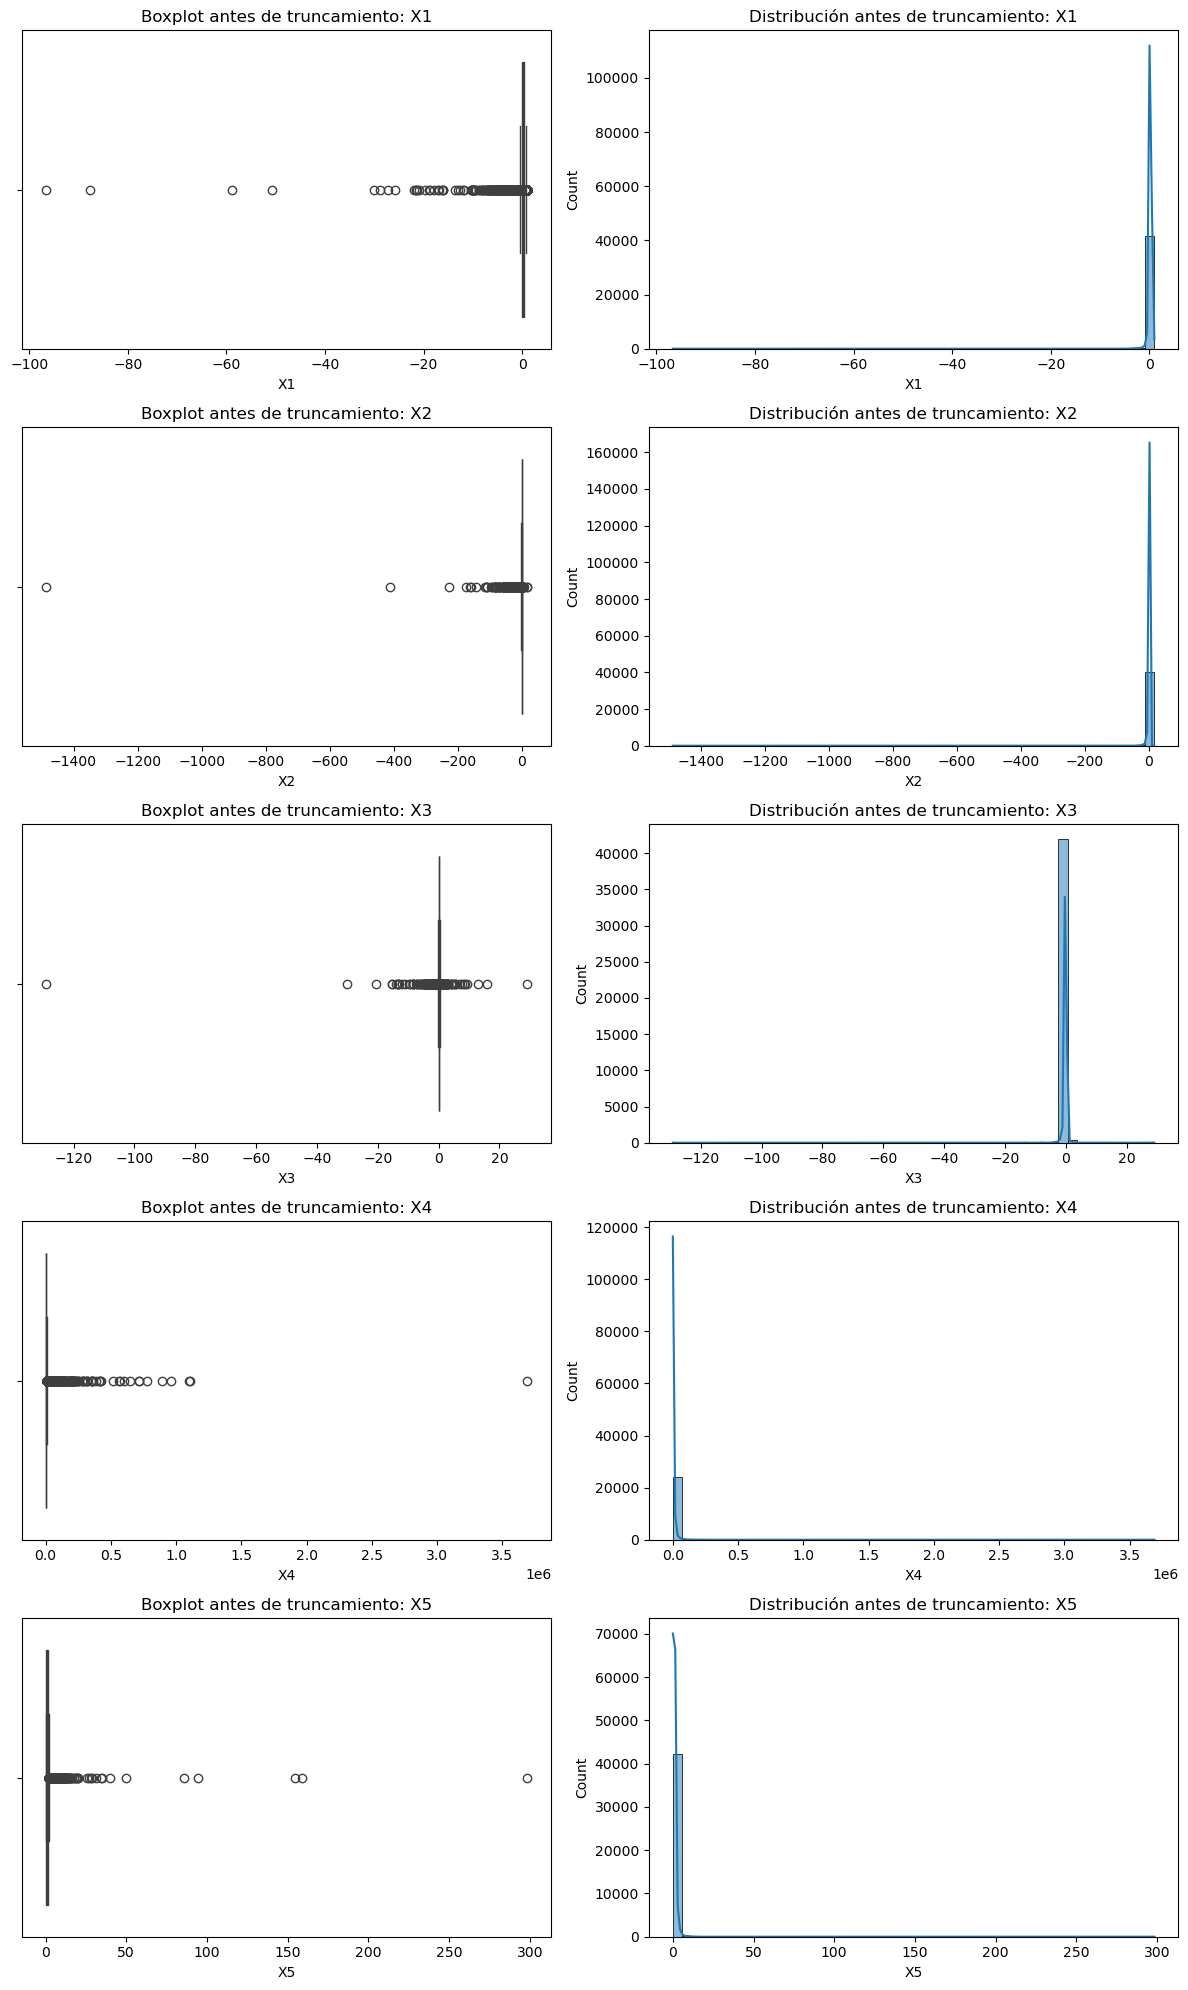

In [269]:
# Cargamos el dataframe limpio ya con X1 a X5
df = df_zlogit.copy()

figures_path = "../outputs/figures"
os.makedirs(figures_path, exist_ok=True)

# Lista de variables a truncar
ratios = ["X1", "X2", "X3", "X4", "X5"]

# Creamos gráficos boxplot y distribución antes de winsorizar
fig, axes = plt.subplots(len(ratios), 2, figsize=(12, 20))

for i, var in enumerate(ratios):
    sns.boxplot(x=df[var], ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot antes de truncamiento: {var}")
    
    sns.histplot(df[var], kde=True, bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribución antes de truncamiento: {var}")

plt.tight_layout()
plt.savefig(os.path.join(figures_path, "distribuciones_boxplots_antes.png"), dpi=150)

In [270]:
ratios_iqr = ["X1", "X2", "X3", "X5"]
ratio_pct = "X4"

# Aplicamos winsorizing por IQR
for col in ratios_iqr:
    df = winsorize_iqr(df, col)

df = winsorize_percentiles(df, ratio_pct)

X1: Winsorizado entre -0.781 y 1.151
X2: Winsorizado entre -1.708 y 1.692
X3: Winsorizado entre -0.351 y 0.426
X5: Winsorizado entre -1.494 y 3.139
X4: Winsorizado entre p1 = 8.211 y p99 = 66358.066


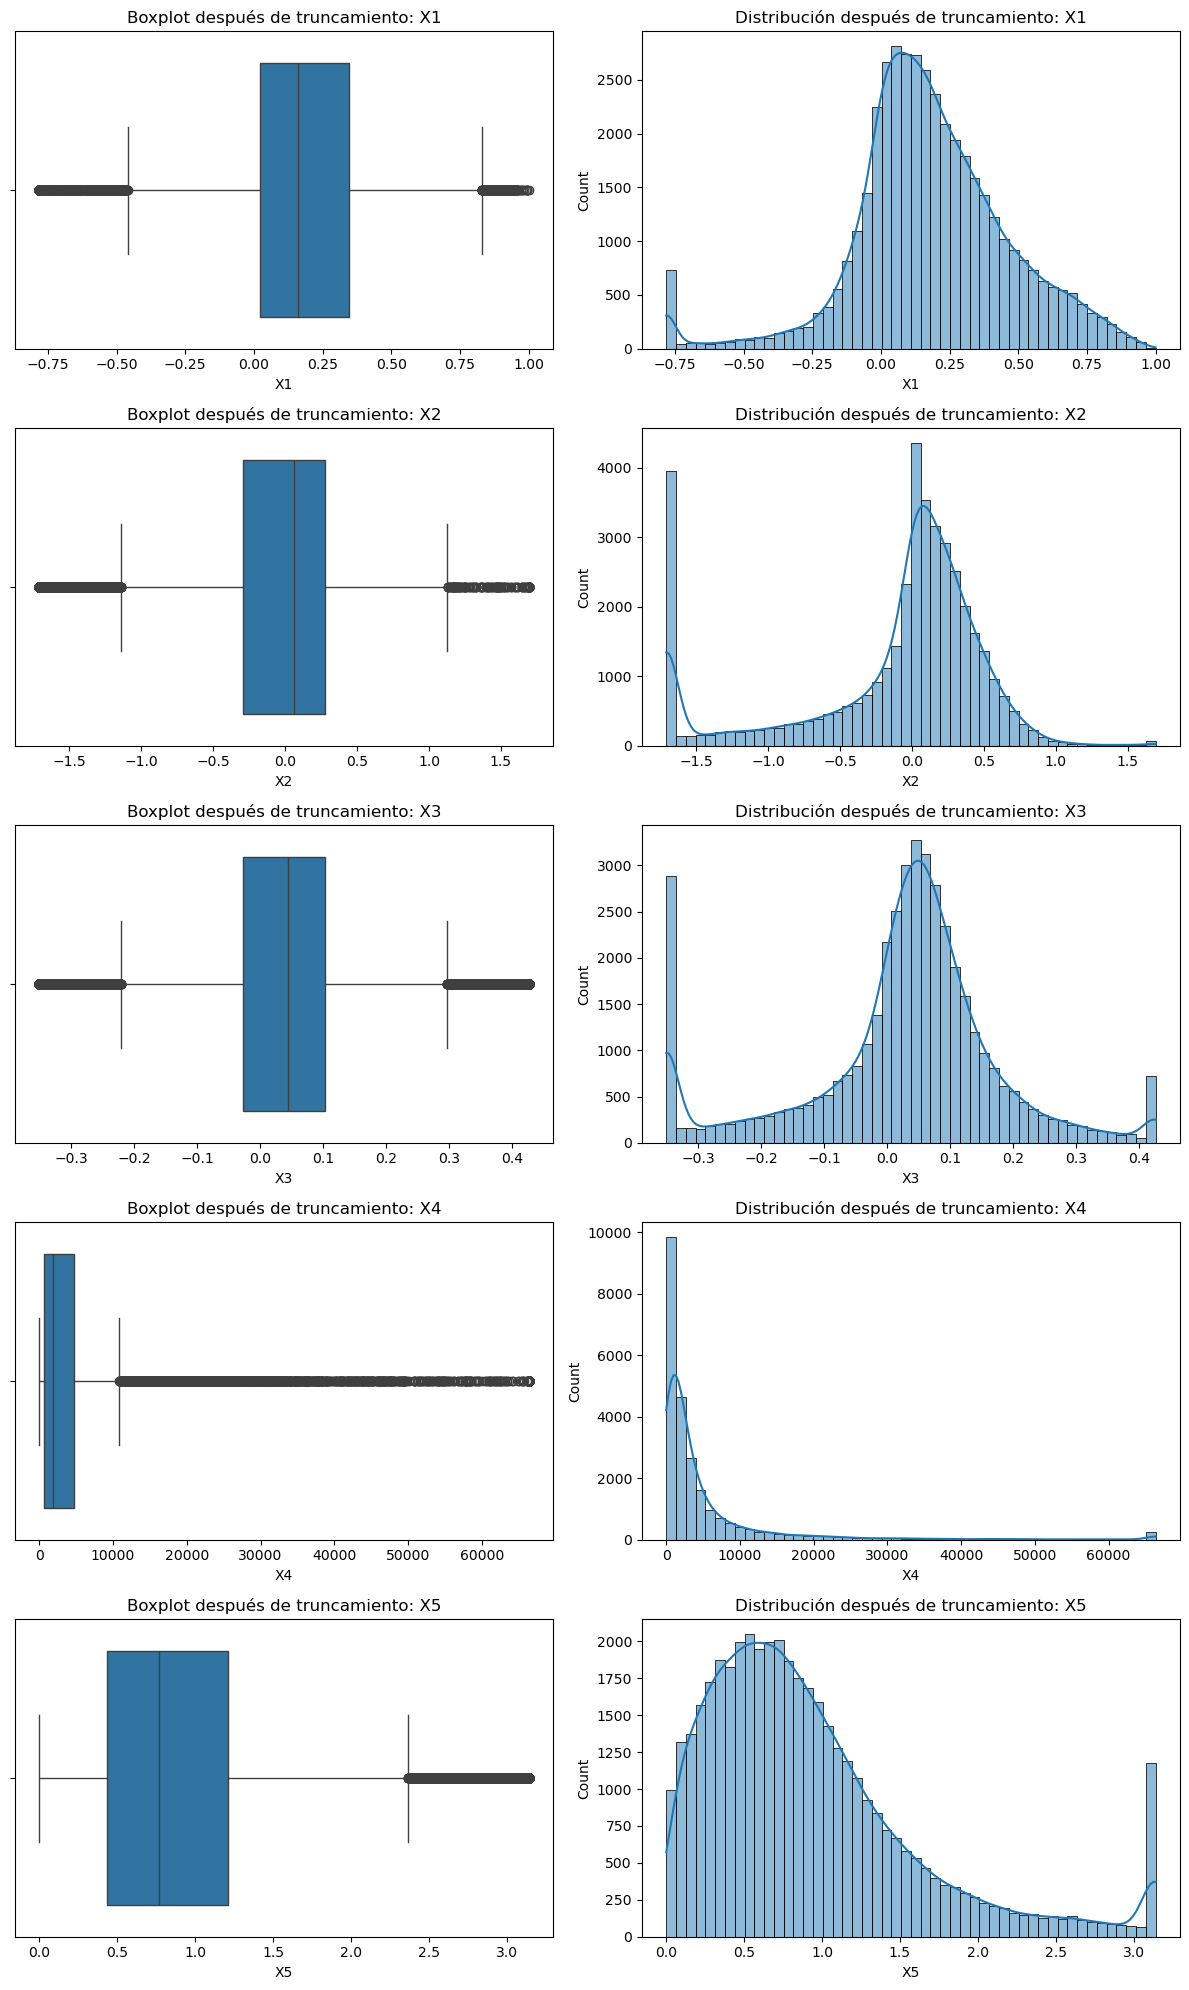

In [271]:
# Lista de variables ya winsorizadas
ratios = ["X1", "X2", "X3", "X4", "X5"]

# Creamos nuevos gráficos para comparar después del winsorizing
fig, axes = plt.subplots(len(ratios), 2, figsize=(12, 20))

for i, var in enumerate(ratios):
    sns.boxplot(x=df[var], ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot después de truncamiento: {var}")

    sns.histplot(df[var], kde=True, bins=50, ax=axes[i, 1])
    axes[i, 1].set_title(f"Distribución después de truncamiento: {var}")

plt.tight_layout()
plt.savefig(os.path.join(figures_path, "distribuciones_boxplots_despues.png"), dpi=150)

## 4. Construcción de la variable dependiente: `is_distressed`

En esta sección construimos una variable binaria `is_distressed` como **proxy de quiebra financiera**.  
Dado que no contamos con una etiqueta explícita de “default” o “bankruptcy”, utilizamos señales financieras severas y objetivas como sustituto, siguiendo la lógica de estudios como Altman (2016) y Barboza (2017).

---

### Criterios aplicados (cada uno suma 1 punto):

| Indicador | Fórmula | Umbral |
|----------|---------|--------|
| Patrimonio neto negativo | `Total Liabilities > Total Assets` | Verdadero |
| EBIT / Activos muy bajo | `EBIT / Total Assets < -0.5` | Verdadero |
| Retained Earnings / Activos muy bajo | `RE / Total Assets < -1.0` | Verdadero |
| Working Capital / Activos negativo | `(CA - CL) / Total Assets < -0.2` | Verdadero |
| Apalancamiento extremo | `Total Debt / Total Assets > 1.0` | Verdadero |
| Intereses > EBIT | `Interest Expense > EBIT` (si EBIT < 0) | Verdadero |

---

### Regla de clasificación:

- Si la empresa **cumple 2 o más condiciones** → `is_distressed = 1`
- En caso contrario → `is_distressed = 0`

---

### Objetivo:

Esto nos permite construir un modelo de riesgo:
- Basado en **criterios contables claros**
- **Replicable**, defendible y útil para consultoría o estudios de crédito
- Que clasifique entre 5–15% de empresas como en distress, lo cual es razonable a nivel empírico

---


In [272]:
# Aplicamos la función definida previamente para generar la variable binaria `is_distressed`
# Esta variable identifica empresas con señales financieras graves (proxy de quiebra)
df["is_distressed"] = calcular_is_distressed(df)

In [273]:
# Validamos la proporción de empresas clasificadas como "en distress" (valor 1)
# Idealmente buscamos un rango razonable de 5–15% del total
df["is_distressed"].value_counts(normalize=True)

is_distressed
0    0.862049
1    0.137951
Name: proportion, dtype: float64

In [274]:
# Mostramos una muestra aleatoria de 5 empresas clasificadas como "distressed"
# Nos permite revisar si efectivamente presentan patrones negativos coherentes
df[df["is_distressed"] == 1].sample(5)

,SP_ENTITY_NAME,SP_ENTITY_ID,SP_GEOGRAPHY,SP_COUNTRY_NAME,SP_COMPANY_TYPE,IQ_INDUSTRY_CLASSIFICATION,SP_COMPANY_STATUS,SP_YEAR_INCORPORATED,SP_PRICE_CLOSE,year,...,IQ_EBIT,IQ_TOTAL_LIAB,IQ_AVG_BASIC_SHARES_OUT,X1,X2,X3,MARKET_VALUE_EQUITY,X4,X5,is_distressed
80882,"Greenwave Technology Solutions, Inc. (NASDAQCM...",4972822,United States and Canada,USA,Public Company,Industrials,Operating,NaN,0.234000,2023,...,-9466.454000,5.086600e+04,87082.0,-0.781416,-1.708419,-0.203966,2.037719e+04,8.210550,0.768510,1
76792,"BridgeBio Pharma, Inc. (NASDAQGS:BBIO)",6959543,United States and Canada,USA,Public Company,Health Care,Operating,2019.0,46.270000,2023,...,-599444.000000,1.888915e+06,162791511.0,0.610837,-1.708419,-0.350518,7.532363e+09,3987.666578,0.017027,1
53656,"Springpoint Senior Living, Inc.",5116842,United States and Canada,USA,Private Company,Health Care,Operating,1916.0,NaN,2021,...,-37559.024000,9.658595e+05,NaN,0.028691,NaN,-0.041200,NaN,NaN,0.207402,1
82207,Jack Nathan Medical Corp. (TSXV:JNH),11546774,United States and Canada,Canada,Public Company,Health Care,Operating,NaN,0.007307,2023,...,-3976.573573,6.237473e+03,84298351.0,-0.480190,-1.708419,-0.350518,6.159819e+05,98.755028,2.449095,1
59911,CanadaBis Capital Inc. (TSXV:CANB),13095401,United States and Canada,Canada,Public Company,Health Care,Operating,2016.0,0.032882,2022,...,817.617915,1.002173e+04,136747550.0,-0.401982,-1.092677,0.067703,4.496565e+06,448.681367,0.761424,1


In [275]:
# Exportamos el dataset con la variable de salida ya construida
df.to_csv("../outputs/zscore_base_modelo_raw.csv", index=False)

## 5. Preparación final del dataset para modelado

Se eliminan observaciones con valores nulos en variables clave y se ordenan las columnas para facilitar el entrenamiento y la interpretación del modelo.

In [276]:
# Eliminamos observaciones con NaN en X1–X5 o en is_distressed
vars_modelo = ["X1", "X2", "X3", "X4", "X5", "is_distressed"]
df_modelo = df.dropna(subset=vars_modelo).reset_index(drop=True)

print(f"Observaciones finales para modelado: {df_modelo.shape[0]}")

Observaciones finales para modelado: 23713


In [277]:
# Ordenamos las variables
cols_ordenadas = [
    "year", "SP_ENTITY_NAME", "SP_ENTITY_ID", "SP_COUNTRY_NAME", "SP_GEOGRAPHY", 
    "SP_COMPANY_TYPE", "SP_COMPANY_STATUS", "SP_YEAR_INCORPORATED", "SP_PRICE_CLOSE",
    "IQ_INDUSTRY_CLASSIFICATION",
    "IQ_TOTAL_ASSETS", "IQ_TOTAL_REV", "IQ_TOTAL_DEBT", "IQ_INTEREST_EXP",
    "IQ_TOTAL_CA", "IQ_TOTAL_CL", "IQ_RETAINED_EARNINGS", "IQ_EBIT", 
    "IQ_TOTAL_LIAB", "MARKET_VALUE_EQUITY", "IQ_AVG_BASIC_SHARES_OUT",
    "X1", "X2", "X3", "X4", "X5",
    "is_distressed"
]

df_modelo = df_modelo[cols_ordenadas]

In [278]:
print(df_modelo["is_distressed"].value_counts(normalize=True))

is_distressed
0    0.842196
1    0.157804
Name: proportion, dtype: float64


In [279]:
# Exportamos el dataset con las variables ordenadas
# Este archivo servirá como base para entrenar modelos logísticos o de clasificación
df_modelo.to_csv("../outputs/zscore_base_modelo.csv", index=False)

In [280]:
# Features y variable dependiente
X = df_modelo[["X1", "X2", "X3", "X4", "X5"]]
y = df_modelo["is_distressed"]

In [281]:
# División estratificada para mantener el balance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [282]:
# Estandarizamos X1-X5
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[["X1", "X2", "X3", "X4", "X5"]])
X_test_scaled = scaler.transform(X_test[["X1", "X2", "X3", "X4", "X5"]])

In [283]:
# Modelo logit con regularización L2 y class_weight
logit = LogisticRegression(
    penalty='l2',
    C=1.0,                 # Puedes hacer tuning de este hiperparámetro
    class_weight='balanced',
    random_state=42,
    solver='liblinear'     # 'liblinear' soporta L1 y L2
)
logit.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [284]:
# Predicciones
y_train_pred = logit.predict(X_train_scaled)
y_test_pred = logit.predict(X_test_scaled)

In [285]:
print("Entrenamiento:\n", classification_report(y_train, y_train_pred))
print("Prueba:\n", classification_report(y_test, y_test_pred))
print("Matriz de confusión (test):\n", confusion_matrix(y_test, y_test_pred))

Entrenamiento:
               precision    recall  f1-score   support

           0       0.99      0.93      0.95     13980
           1       0.70      0.93      0.80      2619

    accuracy                           0.93     16599
   macro avg       0.84      0.93      0.88     16599
weighted avg       0.94      0.93      0.93     16599

Prueba:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96      5991
           1       0.71      0.93      0.81      1123

    accuracy                           0.93      7114
   macro avg       0.85      0.93      0.88      7114
weighted avg       0.94      0.93      0.93      7114

Matriz de confusión (test):
 [[5565  426]
 [  73 1050]]


> **Interpretación:**  
> El modelo alcanza una precisión, recall y f1-score altos tanto en entrenamiento como en prueba, mostrando ausencia de sobreajuste y buen desempeño para ambas clases.

***Calcular y graficar AUC-ROC***

In [286]:
# Probabilidades de predicción (en vez de clase dura)
y_test_proba = logit.predict_proba(X_test_scaled)[:, 1]
y_train_proba = logit.predict_proba(X_train_scaled)[:, 1]

In [287]:
# AUC (solo para clase 1)
auc_test = roc_auc_score(y_test, y_test_proba)
auc_train = roc_auc_score(y_train, y_train_proba)
print(f"AUC-ROC (train): {auc_train:.3f}")
print(f"AUC-ROC (test): {auc_test:.3f}")

AUC-ROC (train): 0.973
AUC-ROC (test): 0.977


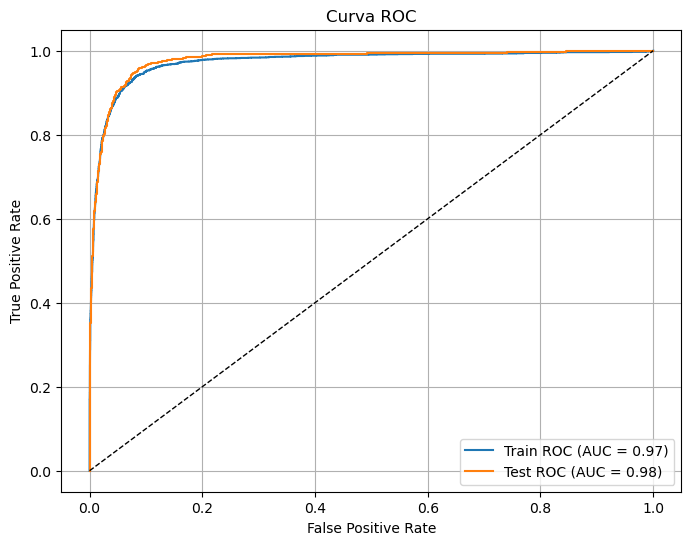

In [288]:
# Curva ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.2f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.savefig(os.path.join(figures_path, "curva_roc.png"), dpi=150)
plt.show()

## 7. Validación con Curva ROC y AUC-ROC

La curva ROC y el AUC permiten evaluar la capacidad discriminante del modelo entre empresas distress y no distress.  
Valores de AUC > 0.95 en train y test indican excelente desempeño y generalización.

In [289]:
from sklearn.model_selection import cross_val_score
# Si usas solo X1–X5 estandarizados:
from sklearn.pipeline import make_pipeline

In [290]:
# Construimos un pipeline que estandariza y ajusta logit en cada fold
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced', random_state=42, solver='liblinear'
    )
)

In [291]:
# Validación cruzada de 5 folds, métrica AUC
cv_scores = cross_val_score(
    pipeline,
    X[["X1", "X2", "X3", "X4", "X5"]],
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
print(f"AUC-ROC por fold: {cv_scores}")
print(f"Promedio AUC-ROC (CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

AUC-ROC por fold: [0.97498009 0.97358488 0.97556415 0.9715315  0.97585315]
Promedio AUC-ROC (CV): 0.974 ± 0.002


In [292]:
# Ejemplo de empresa con ratios extremos
empresa_extrema = pd.DataFrame([{
    "X1": -1.0,
    "X2": -2.0,
    "X3": -0.5,
    "X4": 10,  # muy bajo
    "X5": 0.1
}])
empresa_extrema_scaled = scaler.transform(empresa_extrema)
print("Probabilidad de distress (empresa extrema):", logit.predict_proba(empresa_extrema_scaled)[:,1])

Probabilidad de distress (empresa extrema): [0.99995951]


## 9. Pruebas de robustez y “sanity check”

Se evalúa la probabilidad de distress en empresas con ratios sintéticos extremos (muy sanas o en quiebra) para comprobar que el modelo responde de forma coherente.

In [293]:
# Sanity check: empresa “muy sana”
sana = pd.DataFrame([{
    "X1": 0.8,
    "X2": 0.6,
    "X3": 0.2,
    "X4": 70000,
    "X5": 1.2
}])
sana_scaled = scaler.transform(sana)
print("Probabilidad de distress (empresa sana):", logit.predict_proba(sana_scaled)[:,1])

# Sanity check: empresa “en quiebra”
quiebra = pd.DataFrame([{
    "X1": -1.2,
    "X2": -2.2,
    "X3": -0.5,
    "X4": 20,
    "X5": 0.02
}])
quiebra_scaled = scaler.transform(quiebra)
print("Probabilidad de distress (empresa quiebra):", logit.predict_proba(quiebra_scaled)[:,1])

Probabilidad de distress (empresa sana): [0.00031879]
Probabilidad de distress (empresa quiebra): [0.99998792]


## 10. Exportación de modelo, scaler y resultados

El modelo entrenado y el escalador se guardan como archivos `.pkl` para uso futuro.  
Se exportan las probabilidades de distress y las predicciones para todas las empresas, lo que permite segmentar el riesgo y construir reportes personalizados.

In [294]:
# Exportar modelo y scaler
import joblib
joblib.dump(logit, "../outputs/modelo_zlogit.pkl")
joblib.dump(scaler, "../outputs/escalador_zlogit.pkl")

['../outputs/escalador_zlogit.pkl']

In [295]:
# Exportar probabilidades y clases para todas las empresas
df_modelo["proba_distress"] = logit.predict_proba(scaler.transform(df_modelo[["X1", "X2", "X3", "X4", "X5"]]))[:, 1]
df_modelo["pred_clase"] = logit.predict(scaler.transform(df_modelo[["X1", "X2", "X3", "X4", "X5"]]))
df_modelo.to_csv("../outputs/zscore_modelo_resultados.csv", index=False)

## 11. Diagnóstico exploratorio por segmento

Se analiza la distribución de probabilidades de distress por industria y país para identificar posibles diferencias y ajustar umbrales de riesgo según el segmento, asegurando que la interpretación sea adecuada y defendible para cada grupo de empresas.

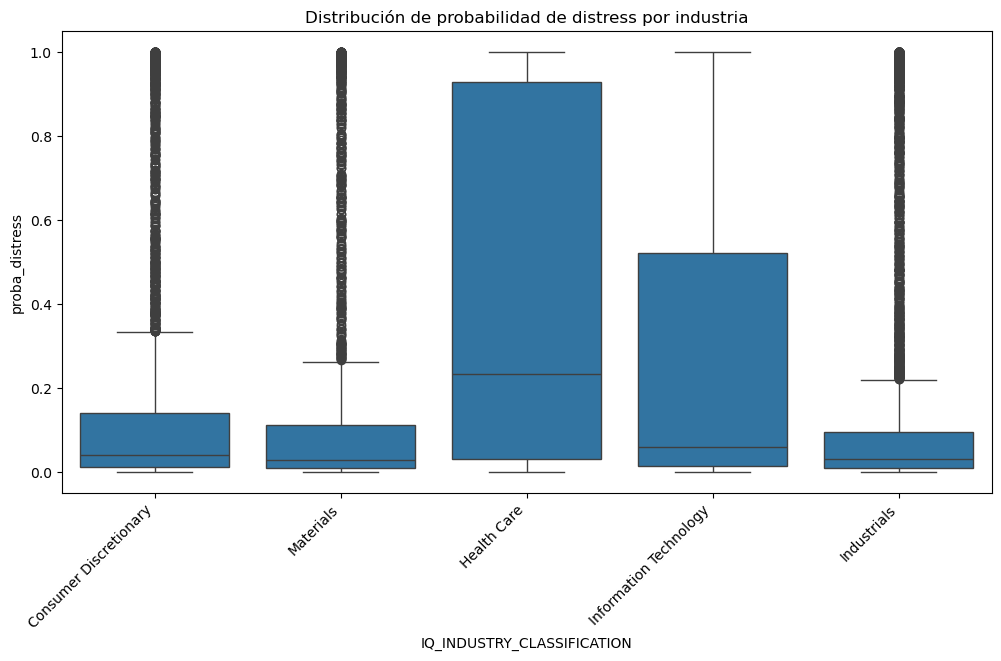

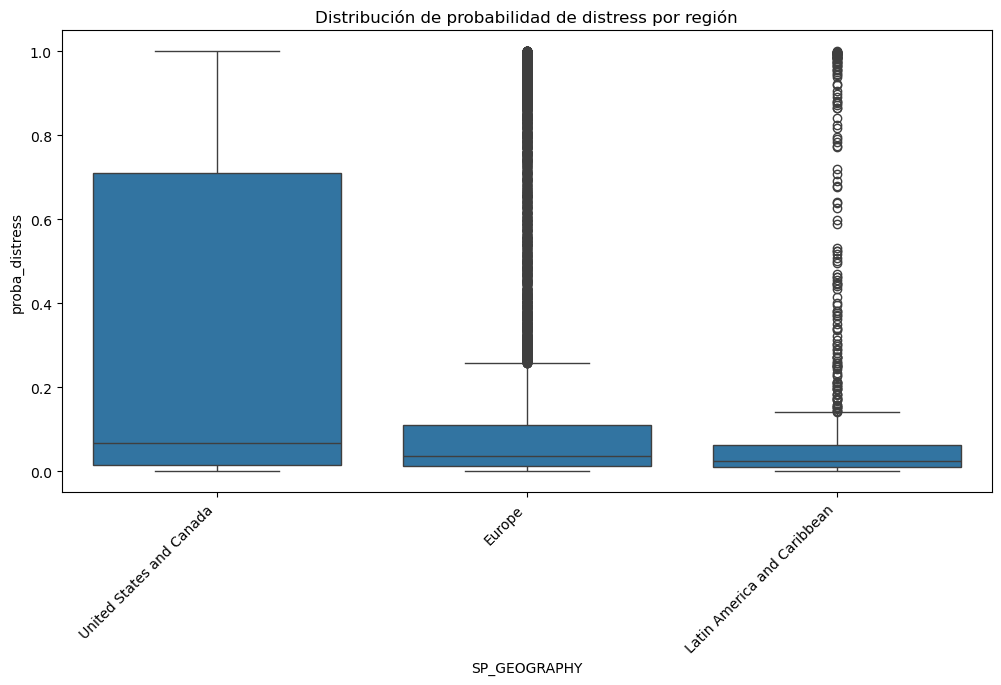

In [296]:
# Diagnóstico exploratorio por segmento

# Boxplot por industria
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_modelo, x="IQ_INDUSTRY_CLASSIFICATION", y="proba_distress")
plt.xticks(rotation=45, ha='right')
plt.title("Distribución de probabilidad de distress por industria")
plt.savefig(os.path.join(figures_path, "distribuciones_probdistress_industria.png"), dpi=150)
plt.show()

# Boxplot por país (si hay varios países)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_modelo, x="SP_GEOGRAPHY", y="proba_distress")
plt.xticks(rotation=45, ha='right')
plt.title("Distribución de probabilidad de distress por región")
plt.savefig(os.path.join(figures_path, "distribuciones_probdistress_region.png"), dpi=150)
plt.show()

## 12. Cálculo de percentiles internos por industria y país

Con el fin de ofrecer interpretaciones defendibles y benchmarking relevante para distintos sectores y geografías, calculamos los **percentiles internos de la probabilidad de distress** (`proba_distress`) por industria y por país. Este enfoque sigue la literatura internacional (Altman, 2016; Barboza, 2017) y las mejores prácticas en consultoría de riesgo, evitando el uso de cortes universales que pueden distorsionar la verdadera distribución del riesgo en cada segmento.

**Metodología:**
- Se calculan los percentiles P10, P25, Mediana, P75 y P90 de `proba_distress` para cada industria y geografía relevante.
- Se genera una tabla ordenada por la mediana de riesgo para facilitar la identificación de los sectores más expuestos y permitir cortes internos defendibles.
- Se visualiza la distribución mediante boxplots ordenados, facilitando la comunicación clara del riesgo relativo entre sectores.

**Interpretación:**
- Un mismo valor de `proba_distress` puede indicar distinto nivel de riesgo dependiendo de la industria o país.
- Esta tabla de percentiles es la base para definir umbrales de “alto”, “medio” y “bajo” riesgo *relativos al segmento*, y para ofrecer recomendaciones personalizadas a cada cliente o portafolio.
- Permite comunicar, por ejemplo, si una empresa está por arriba del P90 de su sector (alto riesgo) o por debajo de la mediana (bajo riesgo relativo).

> **Nota:** Los percentiles y boxplots se actualizan automáticamente con cada corrida del modelo, asegurando que los benchmarks reflejan siempre la última información disponible.

In [297]:
# Agrupar por industria y calcular percentiles internos
percentiles = [0.10, 0.25, 0.5, 0.75, 0.90]

tabla_percentiles_industria = (
    df_modelo.groupby("IQ_INDUSTRY_CLASSIFICATION")["proba_distress"]
    .quantile(percentiles)
    .unstack(level=-1)
    .reset_index()
)

In [298]:
# Renombramos columnas para claridad
tabla_percentiles_industria.columns = [
    "Industria", "P10", "P25", "Mediana", "P75", "P90"
]

# Ordenamos por mediana descendente para visualizar sectores más riesgosos arriba
tabla_percentiles_industria = tabla_percentiles_industria.sort_values("Mediana", ascending=False)
print(tabla_percentiles_industria)

                Industria       P10       P25   Mediana       P75       P90
1             Health Care  0.006653  0.032010  0.234848  0.929115  0.983533
3  Information Technology  0.003885  0.014085  0.060226  0.521416  0.974455
0  Consumer Discretionary  0.003384  0.011915  0.041417  0.141190  0.711903
2             Industrials  0.004046  0.011350  0.031915  0.095115  0.696388
4               Materials  0.003793  0.010489  0.028678  0.111825  0.803068


In [299]:
# Por país
tabla_percentiles_pais = (
    df_modelo.groupby("SP_GEOGRAPHY")["proba_distress"]
    .quantile(percentiles)
    .unstack(level=-1)
    .reset_index()
)
tabla_percentiles_pais.columns = [
    "Geografía", "P10", "P25", "Mediana", "P75", "P90"
]
print(tabla_percentiles_pais)

                     Geografía       P10       P25   Mediana       P75  \
0                       Europe  0.004350  0.012262  0.036304  0.110655   
1  Latin America and Caribbean  0.004422  0.010352  0.025207  0.062729   
2     United States and Canada  0.004088  0.015141  0.068376  0.709579   

        P90  
0  0.655070  
1  0.285328  
2  0.978523  


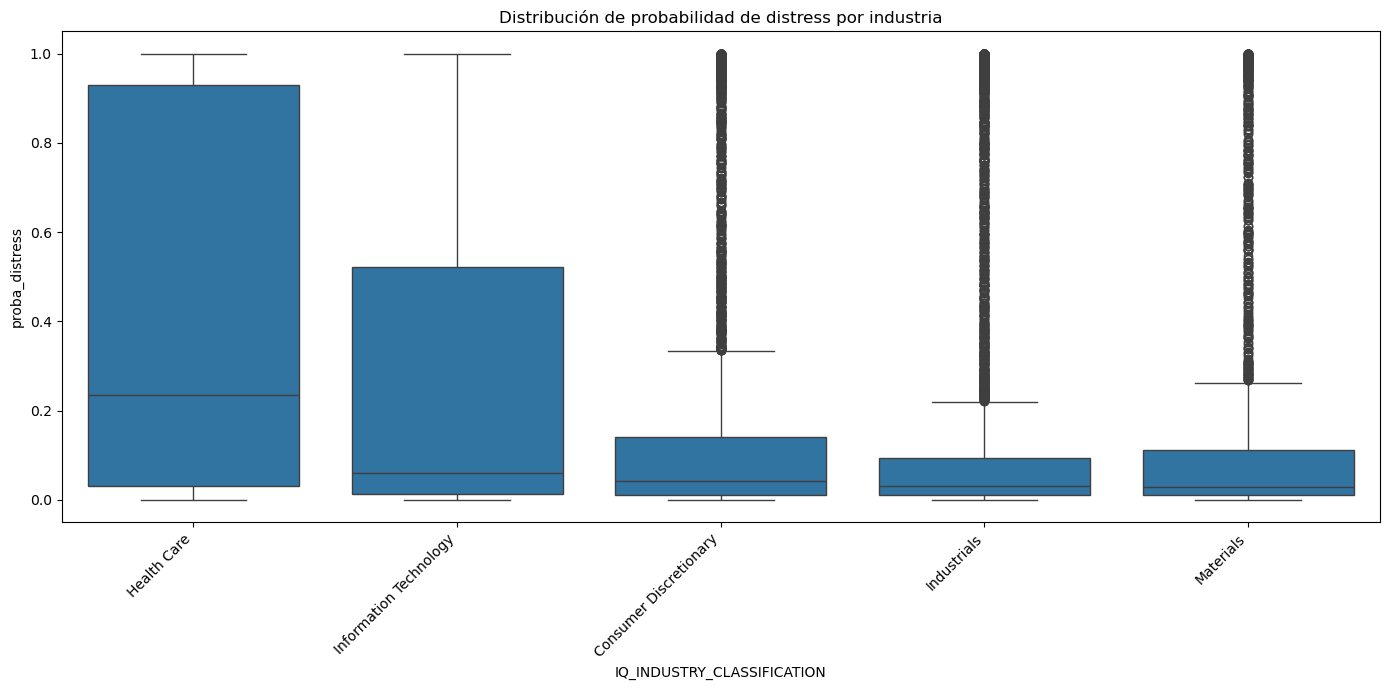

In [300]:
# Boxplots ordenados por industria
plt.figure(figsize=(14, 7))
order = tabla_percentiles_industria.sort_values("Mediana", ascending=False)["Industria"]
sns.boxplot(data=df_modelo, x="IQ_INDUSTRY_CLASSIFICATION", y="proba_distress", order=order)
plt.xticks(rotation=45, ha='right')
plt.title("Distribución de probabilidad de distress por industria")
plt.tight_layout()
plt.show()

## 13. Riesgo relativo por sector y rating estimado

Con la probabilidad de distress calculada para cada empresa, automatizamos la asignación de **categorías de riesgo relativo** ("Bajo", "Medio", "Alto riesgo") en función de los percentiles internos de su propio sector, siguiendo lo recomendado en la literatura (Altman 2016, benchmarking internacional):

- **Bajo riesgo:** Empresa con probabilidad de distress menor a la mediana de su industria.
- **Medio riesgo:** Entre la mediana y el percentil 90 de su industria.
- **Alto riesgo:** Igual o mayor al percentil 90 de su industria (el 10% más riesgoso).

Este enfoque permite interpretar el riesgo en **términos relativos**, es decir, comparando cada empresa con sus verdaderos pares sectoriales, y evita los sesgos que tendrían cortes universales.

Adicionalmente, se estimó el **rating crediticio equivalente** para cada empresa usando la tabla propuesta por Altman (2016), que asocia intervalos de probabilidad de distress con escalas tipo S&P/Moody's (AAA/AA, A, BBB, BB, B, CCC/D). Este rating es una referencia consultiva y no equivale a una calificación oficial.

**Resultados:**
- Se generó un reporte con la industria, probabilidad de distress, categoría de riesgo relativo y rating estimado para cada empresa.
- Esta información permite comunicar con claridad la posición de una empresa respecto a su sector y estimar su nivel de riesgo para decisiones de crédito, pricing y benchmarking.

> **Nota:** Los percentiles y ratings se calculan con base en la muestra disponible; se recomienda actualizar estas referencias regularmente y comunicar a los usuarios que los ratings son aproximaciones defendibles para consultoría, no sustitutos de una calificación oficial.

El archivo final puede ser utilizado para dashboards, reportes personalizados y análisis de portafolios.

In [306]:
# Paso 1: Merge de percentiles por industria a cada empresa
# Usamos tabla_percentiles_industria del análisis anterior
df_equiv = df_modelo.merge(tabla_percentiles_industria, left_on="IQ_INDUSTRY_CLASSIFICATION", right_on="Industria", how="left")

In [307]:

# Paso 2: Asignamos categoría de riesgo relativo por sector
df_equiv["riesgo_sector"] = df_equiv.apply(categorizar_riesgo_sector, axis=1)

# Paso 3: Asignar “rating estimado” tipo S&P, con tabla base Altman 2016
df_equiv["rating_estimado"] = df_equiv["proba_distress"].apply(rating_altman)

In [308]:
# Resumen visual y conteos
print(df_equiv[["IQ_INDUSTRY_CLASSIFICATION", "proba_distress", "riesgo_sector", "rating_estimado"]].head())
print(df_equiv["riesgo_sector"].value_counts())
print(df_equiv["rating_estimado"].value_counts())

  IQ_INDUSTRY_CLASSIFICATION  proba_distress riesgo_sector rating_estimado
0     Consumer Discretionary        0.021387   Bajo riesgo               A
1                  Materials        0.970726   Alto riesgo           CCC/D
2                Health Care        0.363174  Medio riesgo           CCC/D
3     Information Technology        0.954983  Medio riesgo           CCC/D
4     Consumer Discretionary        0.396033  Medio riesgo           CCC/D
riesgo_sector
Bajo riesgo     11855
Medio riesgo     9485
Alto riesgo      2373
Name: count, dtype: int64
rating_estimado
AAA/AA    7666
CCC/D     6198
A         3431
BBB       3283
BB        1827
B         1308
Name: count, dtype: int64


In [309]:
# Calcula el percentil relativo de cada empresa dentro de su industria
df_equiv['percentil_industria'] = (
    df_equiv.groupby('IQ_INDUSTRY_CLASSIFICATION')['proba_distress']
    .rank(pct=True)
)

In [310]:
# Exportamos para reporte final
df_equiv.to_csv("../outputs/zscore_modelo_riesgo_equivalencias.csv", index=False)